In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
def passage(matrice, etat):
    """ en fontion d'un état, cette fonction définit aléatoirement le prochain état du marché """
    nvetat = 0
    k = np.random.uniform()
    if k <matrice[etat][0]:
        nvetat =0
    else:
        if k < matrice[etat][0] + matrice[etat][1] and k >= matrice[etat][0]:   
            nvetat = 1
        else:
            nvetat = 2
    return nvetat

#on definit etat 0 = crise, etat 1 = stable, etat 2 = croissance


def probapopulation(etat, vecteurpopulation):
    """Fonction qui modifie l'opinion de la population en fonction de l'état du marché"""
    vecteur = []
    if etat == 0:
        return vecteurpopulation * 0.9
    if etat == 1:
        return vecteurpopulation
    if etat == 2: 
        for e in vecteurpopulation:
            if e*1.1<1:
               vecteur.append(e*1.1)
            else:
                vecteur.append(1)
        return np.array(vecteur)


def prop_investisseurs(etat, vecteurpopulation):
    """fonction qui determine le nombre d'investisseurs en fonction de l'état du marché"""
    if etat == 2:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.4])
    if etat == 1:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.5])
    if etat == 0:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e < 0.4])
    
    return vecteur_investisseurs



def calculer_indice(vecteurindice, vecteur_investisseurs, etat):
    """fonction qui calcule l'indice global du marché en fonction de l'état du marché et du nombre d'investisseurs"""
    res = 0
    for i in range(len(vecteurindice)):
        res = 0
        if etat == 0:
            for inv in vecteur_investisseurs:
                res = res - np.random.normal(0.002, 0.00001)          #on simplifie, tous les prix diminuent lors d'une crise
            # print(res)
            vecteurindice[i] += res
    
        if etat == 2:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0.001, 0.00001)
            vecteurindice[i] += res

        if etat == 1:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0, 0.00001)
            vecteurindice[i] += res
        
        if vecteurindice[i] < 0.01:
            vecteurindice[i] = 0.01
    nv_indice = np.mean(vecteurindice) 
    return nv_indice

#si possible faire un truc degressif qui fait tendre les prix vers 0 à la fin 

def probamatrice(matrice,etat, indice1, indice0, epsilon): 
    """fonction qui permet de modifier la probabilité de la matrice de transition en fonction de la variation de l'indice global des prix"""
    variation = (indice1 - indice0)/max(indice0, 0.01) #pour éviter une division par zéro
    sensibilité = epsilon

    if abs(variation) < 0.0001:
        return matrice
    
    if indice1 <0.01:
        matrice[etat][0] = min(0.99, matrice[etat][0] + sensibilité) 
        matrice[etat][2] = max(0, matrice[etat][2] - sensibilité)
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
        return matrice
    
    transfert_max = 0.1  #securtité pour éviter des variations trop brusques de la matrice de transition

    if variation > 0:

        transfert = min(matrice[etat][0], abs(sensibilité * variation), transfert_max)

        matrice[etat][0] -= transfert 
        matrice[etat][1] += transfert/2
        matrice[etat][2] += transfert/2
    
    elif variation < 0:
        transfert = min(matrice[etat][2], abs(sensibilité * variation), transfert_max)

        matrice[etat][2] -= transfert
        matrice[etat][1] += transfert/2
        matrice[etat][0] += transfert/2

    return matrice

In [5]:
def informe(matrice,etat,vecteurpopulation,prop_informe):
    n_informe=(int(len(vecteurpopulation) * prop_informe))
    liste_informe=[1 for i in range(n_informe)]
    for j in range(len(vecteurpopulation)-n_informe):
        liste_informe.append(0)
    np.random.shuffle(liste_informe)
    vecteur_investisseurs=[]
    for i in range(len(vecteurpopulation)):
        opinion=vecteurpopulation[i]
        if liste_informe[i]==1:
            proba_prochaine_matrice=matrice[etat]
            etat_investit=np.random.choice([0, 1, 2], p=proba_prochaine_matrice)
        else:
            etat_investit=etat
        if etat_investit == 2:
            if opinion > 0.4:
                vecteur_investisseurs.append(opinion)
        if etat_investit == 1:
            if opinion > 0.5:
                vecteur_investisseurs.append(opinion)
        if etat_investit == 0:
            if opinion < 0.4:
                vecteur_investisseurs.append(opinion)
    return vecteur_investisseurs
    



def fonction_cas3(matrice,etat,vecteurpopulation,vecteurindice,n,epsilon):
    nvetat = 0
    vecteur_indices = [1]
    matrice_pop = []
    vecteur_etats = [etat]
    res = 0
    maximum = -1
    prop_informe=0.1
    for i in range(n):
        nvetat = passage(matrice, vecteur_etats[i])

        vecteurpopulation = probapopulation(nvetat, vecteurpopulation)
        matrice_pop.append(vecteurpopulation.copy())

        vecteur_investisseurs = informe(matrice,nvetat, vecteurpopulation,prop_informe)

        nouvel_indice = calculer_indice(vecteurindice, vecteur_investisseurs, nvetat)
        vecteur_indices.append(nouvel_indice)
        
        matrice = probamatrice(matrice, nvetat, vecteur_indices[i+1], vecteur_indices[i],epsilon)

        vecteur_etats.append(nvetat)
        
        if nvetat == etat:
            res += 1
        else:
            res = 1 
            
        if res > maximum:
            maximum = res

    return matrice, vecteur_etats, vecteur_investisseurs, vecteur_indices, matrice_pop, maximum


In [13]:
population = 100
titres2 = 10
res_cas3 = [1]
matrice_cas3 = [[0.9, 0.1 ,0], [0.05,0.9,0.05], [0,0.1,0.9]]  #on a choisi que 3 états, on peut en choisir plus. 


vecteurpopulation1_cas3 = np.random.normal(0.5, 0.15, population) 
vecteurindices1_cas3 = np.array([np.random.uniform() for _ in range(titres2)])

vecteurpopulation2_cas3 = np.random.normal(0.5, 0.15, population) 
vecteurindices2_cas3 = np.array([np.random.uniform() for _ in range(titres2)])

vecteurpopulation3_cas3 = np.random.normal(0.5, 0.15, population) 
vecteurindices3_cas3 = np.array([np.random.uniform() for _ in range(titres2)])

In [14]:
etat2_cas3 = fonction_cas3(matrice=matrice_cas3, etat= 2, vecteurpopulation = vecteurpopulation1_cas3, vecteurindice=vecteurindices1_cas3, n=20, epsilon =0.01)
etat1_cas3 = fonction_cas3(matrice=matrice_cas3, etat= 1, vecteurpopulation = vecteurpopulation2_cas3, vecteurindice=vecteurindices2_cas3, n=20, epsilon =0.01)
etat0_cas3 = fonction_cas3(matrice=matrice_cas3, etat= 0, vecteurpopulation = vecteurpopulation3_cas3, vecteurindice=vecteurindices3_cas3, n=20, epsilon =0.01)

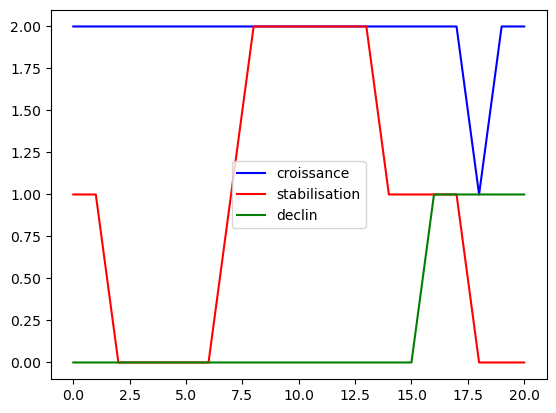

In [15]:
abscisse = np.arange(0, len(etat0_cas3[1]), 1)
plt.plot(abscisse, etat2_cas3[1], color = 'blue', label = "croissance")
plt.plot(abscisse, etat1_cas3[1], color = 'red', label = "stabilisation")
plt.plot(abscisse, etat0_cas3[1], color = 'green', label = "declin")
plt.legend()